This notebook will take the IA2 clusters (https://cosmosimfrazza.myfreesites.net/amr_clusters) and process them for suitability for PLUTO simulations.

In order, this notebook will execute the following:
* centre clusters for selected snapshots,
* extend and interpolate fields as needed to fit the same (smallest) physical domain,
* apodize all fields,
* remove (mass-weighted) average velocities,
* calculate gravitational potentials (gas + DM).

After processing, we can crop and interpolate the cluster as desired.

Calculated relevant values are the final domain size. Also, are the cluster code units (density, length and speed scale).

All fields are saved as binary files. A grid0.out file is also generated.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os, struct
from scipy.interpolate import griddata, RegularGridInterpolator

In [2]:
from utils.enzo import IA2, IA2Data, get_redshift
from utils.clusters import calc_avgvelocity
from utils.units import CGS
from utils.visualize import set_style, DefaultStyle, get_cbar
from utils.gravity import get_gravpot

In [3]:
set_style()

# Load Metadata

In [4]:
def define_units(Delta):
    params_fName = os.path.join(ia2.Path,f'cluster_{Delta}.txt')
    r_Delta, M_Delta, rho_Delta, c_s, t_s = np.loadtxt(params_fName,skiprows=1,max_rows=1,delimiter=',')
    rho_cs = np.loadtxt(os.path.join(ia2.Path,f'rho_c.txt'),skiprows=1)
    idx, = np.where(rho_cs==15)[0]
    rho_c = rho_cs[idx,1]

    global L_0, v_0, rho_0
    global t_0, B_0, p_0
    global K_0, G_0

    L_0 = r_Delta
    v_0 = c_s
    rho_0 = rho_c
    
    t_0 = L_0/v_0 # time unit in seconds
    B_0 = v_0 * (4*np.pi*rho_0)**.5 # Magnetic field unit in Gauss (G)
    p_0 = rho_0*v_0**2 # Pressure unit in dyne/cm^2
    
    K_0 = CGS.mp * v_0**2 / CGS.kB
    G_0 = CGS.G / (1/rho_0/t_0**2)

In [5]:
Path = '/media/yange/MyDrive/2024PhDData/EnzoIA2/E14-R/'
ia2 = IA2Data(Path)

snapshots = 10,11
c = 10

In [6]:
centres = tuple(ia2.get_centre(s) for s in snapshots)
redshifts = tuple(get_redshift(s) for s in snapshots)
dLs = tuple(IA2.dL * (1e3*CGS.pc) * c / (1+z) for z in redshifts)
centres, redshifts, dLs

(((580, 683, 483), (543, 673, 481)),
 (0.4, 0.3),
 (8.706018888403573e+22, 9.37571264905e+22))

In [7]:
define_units(Delta=200)
mu = .5

# Load Raw Data

In [8]:
def load_raw_init():

    snapshot = snapshots[0]
    rho = ia2.get_val('Density',snapshot,c=c) / rho_0
    dm = ia2.get_val('Dark_Matter_Density',snapshot,c=c) / rho_0
    temp = ia2.get_val('Temperature',snapshot,c=c) / K_0
    vx1 = ia2.get_val('x-velocity',snapshot,c=c) / v_0
    vx2 = ia2.get_val('y-velocity',snapshot,c=c) / v_0
    vx3 = ia2.get_val('z-velocity',snapshot,c=c) / v_0
    Bx1 = ia2.get_val('Bx',snapshot,c=c) / B_0
    Bx2 = ia2.get_val('By',snapshot,c=c) / B_0
    Bx3 = ia2.get_val('Bz',snapshot,c=c) / B_0
    prs = rho*temp/mu

    global vals_raw
    vals_raw = {
        'rho' : rho,
        'prs' : prs,
        'dm' : dm,
        'vx1' : vx1,
        'vx2' : vx2,
        'vx3' : vx3,
        'Bx1' : Bx1,
        'Bx2' : Bx2,
        'Bx3' : Bx3,
    }

def load_rawdens():

    global vals_dens_raw

    vals_dens_raw = {s : {
        'rho' : ia2.get_val('Density',s,c=c) / rho_0,
        'dm' : ia2.get_val('Dark_Matter_Density',s,c=c) / rho_0,
    } for s in snapshots}

In [9]:
load_raw_init()
load_rawdens()

# Interpolate DMs
Depreciated

# Centre Domains

In [10]:
def centre_domain(centre, val):

    shape = val.shape
    pads = []
    for cen,sh in zip(centre,shape):
        pads.append([])
        if cen<sh//2:
            pads[-1].append(sh-cen*2)
            pads[-1].append(0)
        else:
            pads[-1].append(0)
            pads[-1].append(cen*2-sh)

    shape_final = max([sh+max(pad) for pad,sh in zip(pads,val.shape)])
    
    ret = np.zeros((shape_final,)*val.ndim)
    slices = []
    for pad,sh in zip(pads,val.shape):
        _pad = (shape_final - (sh + sum(pad)))//2
        # print(_pad)
        pad[0] += _pad
        pad[1] += _pad
        slices.append(slice(pad[0],shape_final-pad[1]))
    slices = tuple(slices)
    ret[slices] = val
    
    return ret

In [11]:
vals_cen = {key : centre_domain(tuple(cen//c for cen in centres[0]),val) for key,val in vals_raw.items()}
vals_dens_cen = {s : {
    key : centre_domain(tuple(cen//c for cen in centre),val) for centre,(key,val) in zip(centres,vals_dens_raw[s].items())
} for s in snapshots}

# Match Domains

In [12]:
def extend_domain(shape_ext,val):
    
    bg = np.zeros(shape_ext)
    
    shape = val.shape
    
    pads = tuple(sh_bg-sh for sh,sh_bg in zip(shape,shape_ext))

    slices = tuple(slice(pad//2,-pad//2) for pad in pads)
    slices = []
    for pad,sh in zip(pads,shape_ext):
        if pad==0:
            slices.append(slice(0,sh))
        else:
            slices.append(slice(pad//2,-pad//2))
    slices = tuple(slices)
    
    ret = bg.copy()
    ret[slices] += val

    return ret

def interpolate(shape_int,val):

    shape = val.shape
    xyz = tuple(np.arange(0,sh) for sh in shape)

    xyx_points = (np.linspace(_x[0],_x[-1],sh) for _x,sh in zip(xyz,shape_int))
    points = np.vstack([X.ravel() for X in np.meshgrid(*xyx_points,indexing='ij')]).T
    ret = RegularGridInterpolator(xyz,val)(points).reshape(shape_int)

    return ret

In [13]:
_L_cens = []
for i,s in enumerate(snapshots):
    _L_cens.append(dLs[i]/L_0 * vals_dens_cen[s]['rho'].shape[0])

vals_dens_ext = {}
_shape_exts = []
for i,s in enumerate(snapshots):
    _shape_exts.append(round(max(_L_cens)/_L_cens[i] * vals_dens_cen[s]['rho'].shape[0]))
    shape_ext = (_shape_exts[-1],)*3
    vals_dens_ext.update({s : {key : extend_domain(shape_ext,val) for key,val in vals_dens_cen[s].items()}})
    if i==0:
        vals_ext = {key : extend_domain(shape_ext,val) for key,val in vals_cen.items()}

vals_dens_int = {}
shape_int = (max(_shape_exts),)*3
for i,s in enumerate(snapshots):
    vals_dens_int.update({s : {key : interpolate(shape_int,val) for key,val in vals_dens_ext[s].items()}})
    if i==0:
        vals_int = {key : interpolate(shape_int,val) for key,val in vals_ext.items()}

DefaultStyle catalogue does not include dm. Returning to default.


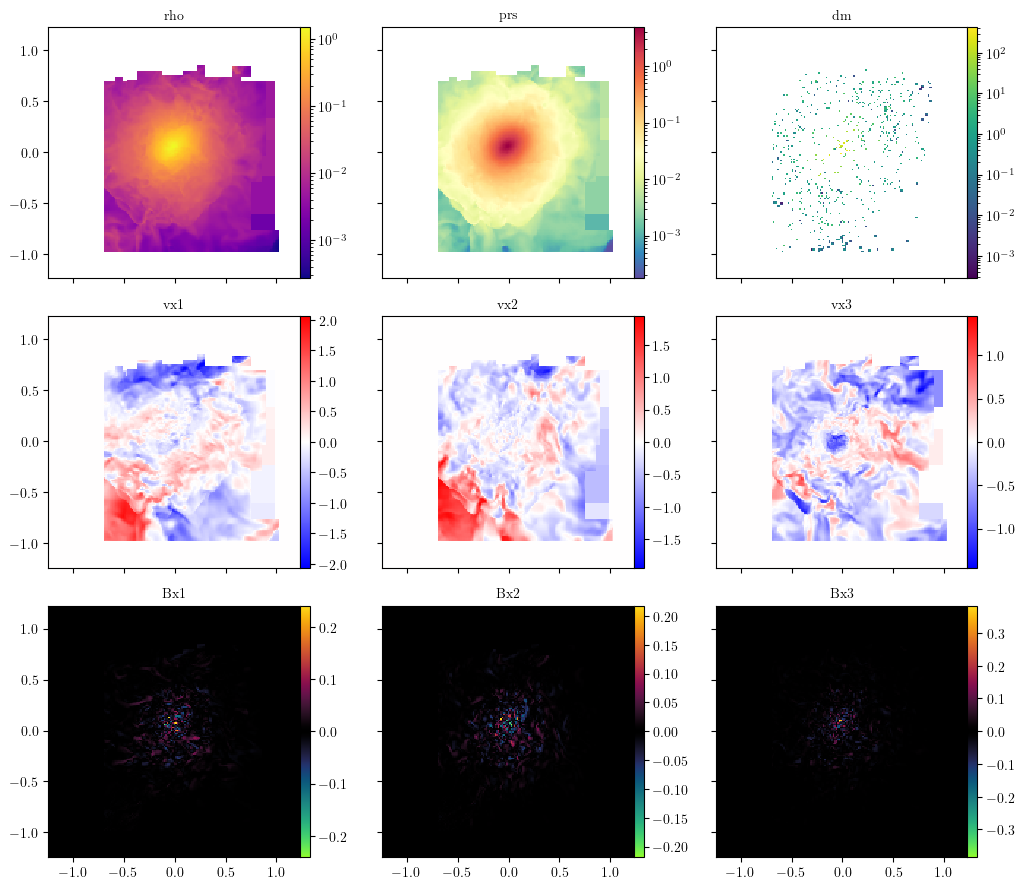

DefaultStyle catalogue does not include dm. Returning to default.
DefaultStyle catalogue does not include dm. Returning to default.


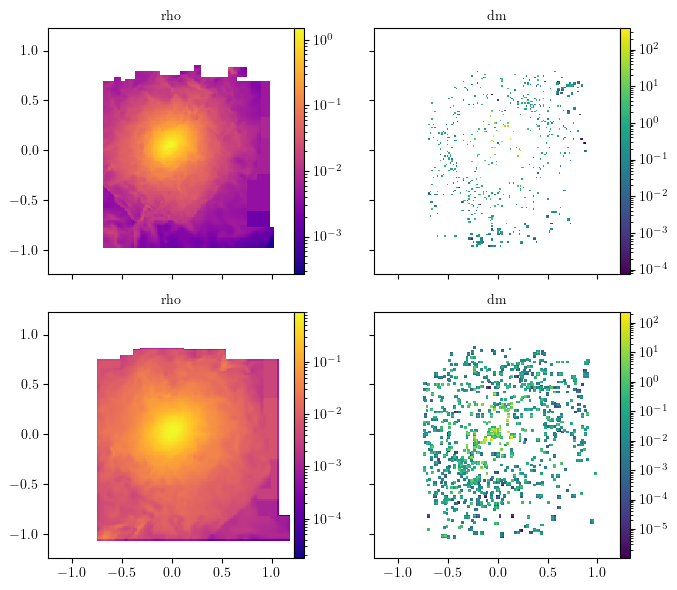

In [14]:
def plot_vals(vals,L,los=0):
    """
    Not equipped to plot for user defined centres.
    """

    shape = vals['rho'].shape[0]
    x, y = (np.arange(-shape//2,shape//2)*L/shape,)*2

    fig, axes = plt.subplots(3,3,figsize=(10.5,9),sharex=True,sharey=True,tight_layout=True)
    for ax, (key, val) in zip(axes.flatten(),vals.items()):
        if los==0:
            val = val[shape//2]
        elif los==1:
            val = val[:,shape//2]
        else:
            val = val[:,:,shape//2]
        norm = None
        if key in {'rho','dm','prs'}:
            norm = LogNorm()
            # pass
        if key.startswith('vx') or key.startswith('Bx'):
            vmax = np.abs(val).max()
            vmin = -vmax
        else:
            vmin, vmax = None, None
        # print(vmin,vmax,norm)
        cmap = DefaultStyle.get_varkwargs(key)['cbar_cmap']
        ax.set_aspect(1)
        ax.set_title(key)
        im = ax.pcolormesh(x,y,val,cmap=cmap,vmin=vmin,vmax=vmax,norm=norm)
        cbar = get_cbar(im,fig,ax,cbar_pad=0,cbar_size=.1)
    plt.show()

def plot_dens(vals,L=None,los=0):

    fig, axes = plt.subplots(len(snapshots),2,figsize=(7,3*len(snapshots)),sharex=True,sharey=True,tight_layout=True)
    
    for i,s in enumerate(snapshots):
        shape = vals[s]['rho'].shape[0]
        if L:
            x, y = (np.arange(-shape//2,shape//2)*L/shape,)*2
        else:
            x, y = (np.arange(-shape//2,shape//2),)*2

        for ax, (key, val) in zip(axes[i],vals[s].items()):
            if los==0:
                val = val[shape//2]
            elif los==1:
                val = val[:,shape//2]
            else:
                val = val[:,:,shape//2]
            norm = None
            if key in {'rho','dm','prs'}:
                norm = LogNorm()
                # pass
            if key.startswith('vx') or key.startswith('Bx'):
                vmax = np.abs(val).max()
                vmin = -vmax
            else:
                vmin, vmax = None, None
            # print(vmin,vmax,norm)
            cmap = DefaultStyle.get_varkwargs(key)['cbar_cmap']
            ax.set_aspect(1)
            ax.set_title(key)
            im = ax.pcolormesh(x,y,val,cmap=cmap,vmin=vmin,vmax=vmax,norm=norm)
            cbar = get_cbar(im,fig,ax,cbar_pad=0,cbar_size=.1)
    plt.show()

if 1:
    plot_vals(vals_int,L=max(_L_cens),los=0)
    plot_dens(vals_dens_int,L=max(_L_cens),los=0)

# Apodise Values

In [15]:
def sigmoid(x,radius,slope):
    return 1/(1+np.exp(slope*(x-radius)))

def get_R(shape,dL):
    xyz = tuple(np.arange(-sh//2,sh//2)*dL for sh in shape)
    XYZ = np.meshgrid(*xyz,indexing='ij')
    R = np.sum([X**2 for X in XYZ],axis=0)**.5
    return R

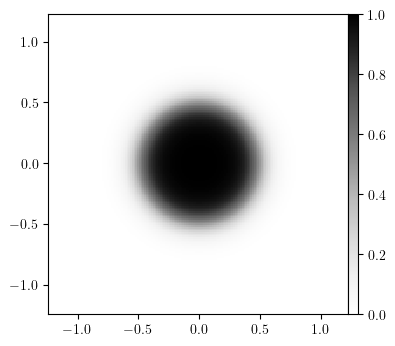

In [16]:
R = get_R(shape_int,max(_L_cens)/shape_int[0])
apodize = sigmoid(R,radius=.5,slope=16.)

def plot_apodize():
    x, y = (np.arange(-shape_int[0]//2,shape_int[0]//2)*max(_L_cens)/shape_int[0],)*2
    fig, ax = plt.subplots(1,1,figsize=(4,4))
    im = ax.pcolormesh(x,y,apodize[shape_int[0]//2],cmap='Greys',vmin=0.,vmax=1.)
    ax.set_aspect(1)
    cbar = get_cbar(im,fig,ax)
    plt.show()

plot_apodize()

In [17]:
vals_apd = {key : val*apodize for key,val in vals_ext.items()}
vals_dens_apd = {s : {key : val*apodize for key,val in vals_dens_int[s].items()} for s in snapshots}

# Add Floor to Density and Pressure Values
Depreciated

In [19]:
H2_a = lambda a : IA2.H_0**2 * (IA2.Omega_r0/a**4 + (IA2.Omega_bm0+IA2.Omega_dm0)/a**3 + IA2.Omega_Lambda0 + IA2.Omega_k0/a**2)
H2_z = lambda z : H2_a(1/(1+z))
rho_cr_z = lambda z: 3*H2_z(z)/(8*np.pi*CGS.G)

rho_cr = rho_cr_z(get_redshift(snapshots[0]))
prs_cr = vals_ext['prs'][vals_ext['prs']>0].min()
# prs_cr = rho_cr/CGS.mp * CGS.kB * 2.75
rho_cr/rho_0, prs_cr/p_0

(np.float64(0.0008615718541848499), np.float64(0.008256187725323915))

# Subtract average velocity

In [20]:
avg_vel = calc_avgvelocity(vals_apd['rho']+vals_apd['dm'],(vals_apd['vx1'],vals_apd['vx2'],vals_apd['vx3']))
vals_apd['vx1_sh'] = vals_apd['vx1']-avg_vel[0]
vals_apd['vx2_sh'] = vals_apd['vx2']-avg_vel[1]
vals_apd['vx3_sh'] = vals_apd['vx3']-avg_vel[2]

# Calculate Gravitational Potentials

In [21]:
def _get_R(shape,dL,centre=(0.,0.,0.,)):
    xyz = tuple(np.arange(-sh//2,sh//2)*dL-cen for sh,cen in zip(shape,centre))
    XYZ = np.meshgrid(*xyz,indexing='ij')
    R = np.sum([X**2 for X in XYZ],axis=0)**.5
    return R

In [22]:
dL = max(_L_cens)/shape_int[0]
slices_int = tuple(slice(sh//2,sh*3//2) for sh in shape_int)

gravpots = {}
for s in snapshots:
    dens_apd = extend_domain((shape_int[0]*2,)*3,vals_dens_apd[s]['rho']+vals_dens_apd[s]['dm'])
    # _R = _get_R(dens_apd.shape, dL, (0.5,0.,0.5))
    # mass = np.zeros(dens_apd.shape)
    # mass[_R<0.1] = 20.0
    # gravpot = get_gravpot(dens_apd+mass,(dL,dL,dL),G=G_0)[slices_int]
    gravpot = get_gravpot(dens_apd,(dL,dL,dL),G=G_0)[slices_int]
    gravpot -= gravpot.max()
    gravpots.update({s : gravpot})

# Crop final grid

In [23]:
def crop_domain(shape_cr,val):

    slices = []
    for sh_cr,sh in zip(shape_cr,val.shape):
        cr = (sh-sh_cr)//2
        slices.append(slice(cr,-cr))
    slices = tuple(slices)

    return val[slices]

In [24]:
vals_save = {
    'rho' : vals_apd['rho'],
    'prs' : vals_apd['prs'],
    'vx1' : vals_apd['vx1_sh'],
    'vx2' : vals_apd['vx2_sh'],
    'vx3' : vals_apd['vx3_sh'],
    'Bx1' : vals_apd['Bx1'],
    'Bx2' : vals_apd['Bx2'],
    'Bx3' : vals_apd['Bx3'],
}
for i,s in enumerate(snapshots):
    vals_save.update({'pot'+str(i) : gravpots[s]})

In [25]:
shape_cr = (128,)*3

In [26]:
vals_save = {key : crop_domain(shape_cr,val) for key, val in vals_save.items()}

# Interpolate final grid

In [27]:
vals_save = {key : interpolate(shape_cr,val) for key, val in vals_save.items()}

DefaultStyle catalogue does not include pot0. Returning to default.
DefaultStyle catalogue does not include pot1. Returning to default.


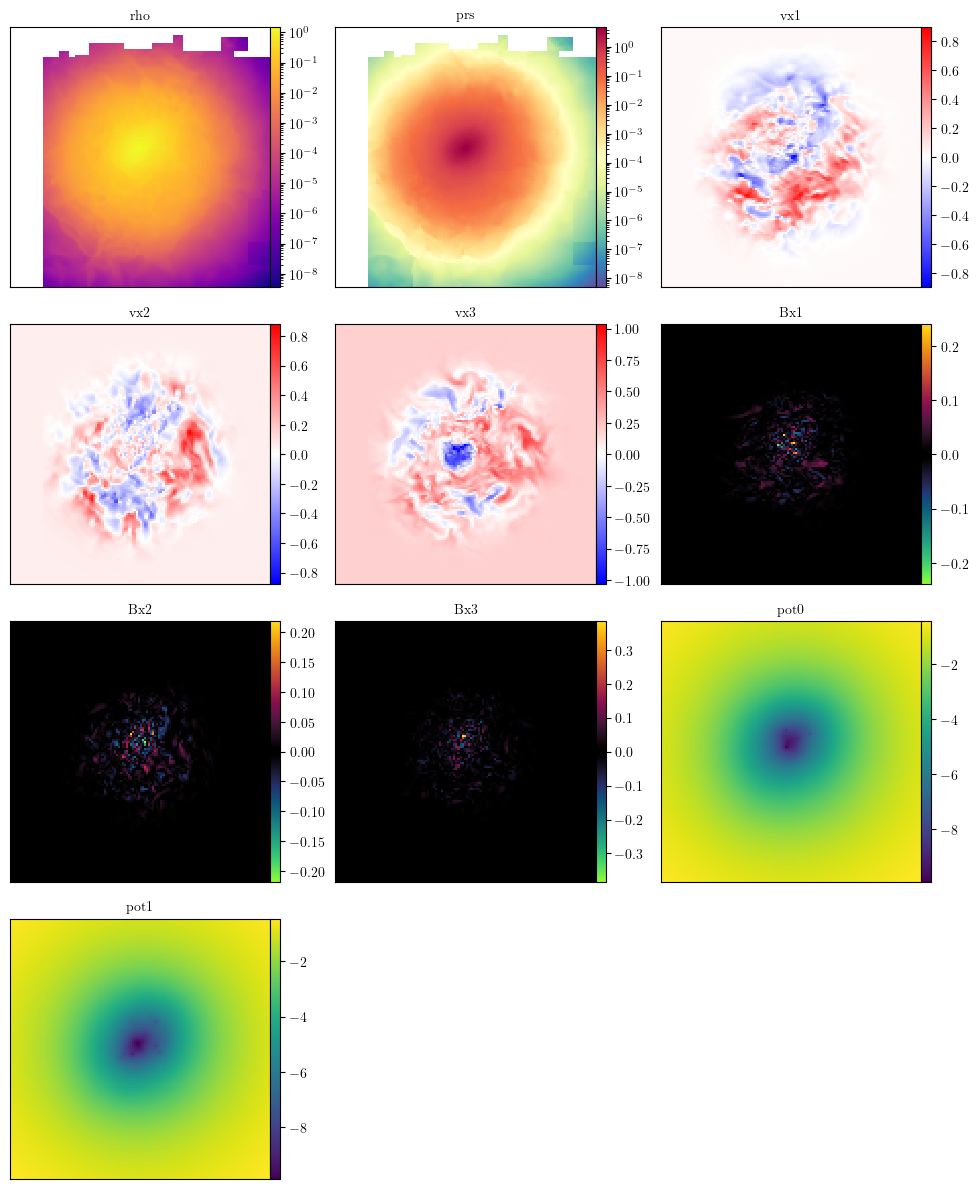

In [30]:
# from matplotlib.colors import LogNorm

fig = plt.figure(figsize=(10,12),tight_layout=True)
for i, (key, val) in enumerate(vals_save.items()):
    ax = fig.add_subplot(4,3,i+1)
    ax.set_xticks([])
    ax.set_yticks([])
    val = val[shape_cr[0]//2]
    norm = None
    if key in {'rho','dm','prs'}:
        norm = LogNorm()
        # norm = None
    if key.startswith('vx') or key.startswith('Bx'):
        vmax = np.abs(val).max()
        vmin = -vmax
    else:
        vmin, vmax = None, None
    cmap = DefaultStyle.get_varkwargs(key)['cbar_cmap']
    ax.set_aspect(1)
    ax.set_title(key)
    im = ax.pcolormesh(val,cmap=cmap,vmin=vmin,vmax=vmax,norm=norm)
    cbar = get_cbar(im,fig,ax,cbar_pad=0,cbar_size=.1)
plt.show()

# Save Data

In [31]:
# savePath = '/media/yange/MyDrive/2024PhDData/pluto-runs/local/IA2/E14_10to11/'
savePath = "/home/yange/Documents/2024PhD/Project/plutotests/IA2"

In [32]:
save_names = [key+'0.dbl' for key in vals_save.keys()]
n_points = np.prod(vals_save['rho'].shape)

for i, (key,value) in enumerate(vals_save.items()):
    with open(os.path.join(savePath, f'{key}0.dbl'),'wb') as f_o:   
        f_o.write(struct.pack('<'+'d'*n_points,*(value.T.flatten())))

In [33]:
DIM = 3
shape = vals_save['rho'].shape
L = dL * shape[0]

with open(os.path.join(savePath, 'grid0.out'),'w') as f_o:

    f_o.write("# GEOMETRY:   CARTESIAN\n")

    for d in range(DIM):
        f_o.write(f"{shape[d]}\n")
        for i in range(shape[d]):
            # xL = -0.5 + ((i2-0.5)/(Points_X - 1.))
            # xR = -0.5 + ((i2+0.5)/(Points_X - 1.))
            # xL = (i-0.5)/(shape[d] - 1.)
            # xR = (i+0.5)/(shape[d] - 1.)
            xL = -0.5 + (i-0.5)/(shape[d] - 1.)
            xR = -0.5 + (i+0.5)/(shape[d] - 1.)
            # print(xL,xR)
            xL *= L
            xR *= L
            f_o.write("{:d}   {:12.6e}  {:12.6e}\n".format(i+1, xL, xR));

In [34]:
print(f"L = {L}, L/2 = {L/2}")
print(f"rho_0 = {rho_0}")
print(f"L_0 = {L_0}")
print(f"v_0 = {v_0}")
print(f"shape = {shape}")
print()
print(f"rho_cr = {rho_cr/rho_0}")
print(f"prs_cr = {prs_cr/p_0}")

L = 1.8374735635572035, L/2 = 0.9187367817786017
rho_0 = 1.6387084621353854e-26
L_0 = 6.075537340319067e+24
v_0 = 79251374.83761768
shape = (128, 128, 128)

rho_cr = 0.0008615718541848499
prs_cr = 0.008256187725323915


In [35]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
cosmo = FlatLambdaCDM(H0=IA2.h_0*100*u.km/u.s/u.Mpc, Om0=IA2.Omega_dm0+IA2.Omega_bm0)

times = []
# times = {}
for s in snapshots:
    z = get_redshift(s)
    # data.update({s : cosmo.age(z).value*(1e9*CGS.yr)/t_0})
    times.append(cosmo.age(z).value*(1e9*CGS.yr)/t_0)
times = np.array(times)

In [37]:
times_list = times-times.min()

In [38]:
times_list[-1]/20

np.float64(0.017659797636107255)

Fluff

In [53]:
+0.021533 -0.007178, L/86/2

(0.014355, np.float64(0.014355262215290652))

In [54]:
(-1.249077e+00 + -1.220028e+00) * 0.5

-1.2345525

In [57]:
-1.248908 + 1.277618, L/86

(0.028710000000000013, np.float64(0.028710524430581304))

In [63]:
1.24890748 -1.22019695, np.arange(-1.277618,1.277618,L/86,), np.arange(-L/2,L/2,L/86,)

(0.0287105299999999,
 array([-1.277618  , -1.24890748, -1.22019695, -1.19148643, -1.1627759 ,
        -1.13406538, -1.10535485, -1.07664433, -1.0479338 , -1.01922328,
        -0.99051276, -0.96180223, -0.93309171, -0.90438118, -0.87567066,
        -0.84696013, -0.81824961, -0.78953908, -0.76082856, -0.73211804,
        -0.70340751, -0.67469699, -0.64598646, -0.61727594, -0.58856541,
        -0.55985489, -0.53114436, -0.50243384, -0.47372332, -0.44501279,
        -0.41630227, -0.38759174, -0.35888122, -0.33017069, -0.30146017,
        -0.27274964, -0.24403912, -0.2153286 , -0.18661807, -0.15790755,
        -0.12919702, -0.1004865 , -0.07177597, -0.04306545, -0.01435493,
         0.0143556 ,  0.04306612,  0.07177665,  0.10048717,  0.1291977 ,
         0.15790822,  0.18661875,  0.21532927,  0.24403979,  0.27275032,
         0.30146084,  0.33017137,  0.35888189,  0.38759242,  0.41630294,
         0.44501347,  0.47372399,  0.50243451,  0.53114504,  0.55985556,
         0.58856609,  0.617276

In [64]:
xvals = [
    -1.277618,
    -1.248908,
    -1.220197,
    -1.191487,
    -1.162776,
    -1.134066,
    -1.105355,
    -1.076645,
    -1.047934,
    -1.019224,
    -0.990513,
    -0.961803,
    -0.933092,
    -0.904382,
    -0.875671,
    -0.846960,
    -0.818250,
    -0.789539,
    -0.760829,
    -0.732118,
    -0.703408,
    -0.674697,
    -0.645987,
    -0.617276,
    -0.588566,
    -0.559855,
    -0.531145,
    -0.502434,
    -0.473724,
    -0.445013,
    -0.416303,
    -0.387592,
    -0.358882,
    -0.330171,
    -0.301461,
    -0.272750,
    -0.244039,
    -0.215329,
    -0.186618,
    -0.157908,
    -0.129197,
    -0.100487,
    -0.071776,
    -0.043066,
    -0.014355,
    0.014355,
    0.043066,
    0.071776,
    0.100487,
    0.129197,
    0.157908,
    0.186618,
    0.215329,
    0.244039,
    0.272750,
    0.301461,
    0.330171,
    0.358882,
    0.387592,
    0.416303,
    0.445013,
    0.473724,
    0.502434,
    0.531145,
    0.559855,
    0.588566,
    0.617276,
    0.645987,
    0.674697,
    0.703408,
    0.732118,
    0.760829,
    0.789539,
    0.818250,
    0.846960,
    0.875671,
    0.904382,
    0.933092,
    0.961803,
    0.990513,
    1.019224,
    1.047934,
    1.076645,
    1.105355,
    1.134066,
    1.162776,
    1.191487,
    1.220197,
    1.248908,
    1.277618,
]

In [66]:
len(xvals)

90